In [1]:
%matplotlib widget
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy import constants as const
from astropy import units as u
from astropy.modeling import models, fitting
from astropy.table import Table
from astropy.stats import sigma_clip

import emcee
import corner

import time

import io

# Lets open the file
We will have the tables, plus the line lists and info of the fit:

In [2]:

def open_table(file_path):
    # Read the file as a generic ASCII table
    t = Table.read(file_path, format='ascii.csv', data_start=2, header_start=1)
    
    # Reopen to get the first line (units)
    with open(file_path, 'r') as f:
        units_line = f.readline().strip().split(',')
    
    # Assign units to each column
    for col, unit_str in zip(t.colnames, units_line):
        unit_str = unit_str.strip()
        if unit_str and unit_str != '-':
            try:
                t[col].unit = u.Unit(unit_str)
            except Exception:
                # silently ignore invalid unit strings
                t[col].unit = None
        else:
            t[col].unit = None
    
    return t

def go_through_dir_files(dir_path, nigth, fiber):
    files_data = {}
    for filename in os.listdir(dir_path):
        if filename.endswith('.csv') and nigth in filename and fiber in filename:
            file_path = os.path.join(dir_path, filename)
            files_data = open_table(file_path)
    return files_data

night = '20250924'
fiber = 'A'
file = go_through_dir_files('Output_spectras', night, fiber)
print()

In [3]:
file

WAVE,FLUX_STACK,ERR_STACK,NCONTRIB,FLUX_STACK_SKYSUB,ERR_STACK_SKYSUB,NCONTRIB_SKYSUB,CONTINUUM,REFLECTANCE,KURUCZ_SHIFTED,WAVENUMBER
Angstrom,erg / (Angstrom s cm2),erg / (Angstrom s cm2),,erg / (Angstrom s cm2),erg / (Angstrom s cm2),,erg / (Angstrom s cm2),,erg / (Angstrom s cm2),1 / cm
float64,float64,float64,int64,float64,float64,int64,float64,float64,float64,float64
3772.2958284835863,nan,nan,0,nan,nan,0,1.2285411345936051e-15,6.810857896534386e-18,134.06078757032975,26509.0556379293
3772.3021197818316,nan,nan,0,nan,nan,0,1.236940487221943e-15,6.810862077312306e-18,134.97725833929442,26509.01142716094
3772.30841109057,nan,nan,0,nan,nan,0,1.2360494836430412e-15,6.8108662581163645e-18,134.87994756790403,26508.9672164663
3772.3147024098,nan,nan,0,nan,nan,0,1.2268930384776867e-15,6.8108704389465596e-18,133.8806975851882,26508.923005845405
3772.3209937395227,nan,nan,0,nan,nan,0,1.212009452447264e-15,6.810874619802895e-18,132.25649366193045,26508.878795298235
3772.327285079737,nan,nan,0,nan,nan,0,1.1949267366681313e-15,6.810878800685367e-18,130.39231917213547,26508.834584824806
3772.3335764304447,nan,nan,0,nan,nan,0,1.1795601660393784e-15,6.810882981593978e-18,128.71541536275421,26508.790374425105
3772.3398677916457,nan,nan,0,nan,nan,0,1.169386402794513e-15,6.810887162528729e-18,127.60516037393472,26508.746164099128


In [4]:
ephemeris_summary_path = Path('Ephemeris/ephemeris_means_by_observation.csv')
if ephemeris_summary_path.exists():
    ephemeris_means_table = Table.read(ephemeris_summary_path, format='ascii.csv')
    print(f"Loaded ephemeris summary for {len(ephemeris_means_table)} observations.")
    ephemeris_means_table[:5]

    def _row_to_python(row):
        record = {}
        for col in ephemeris_means_table.colnames:
            val = row[col]
            if hasattr(val, 'item'):
                try:
                    val = val.item()
                except Exception:
                    val = val.tolist()
            elif hasattr(val, 'tolist') and not isinstance(val, (str, bytes)):
                val = val.tolist()
            record[col] = val
        return record

    ephemeris_means = {}
    for idx, row in enumerate(ephemeris_means_table):
        if 'date_obs' in ephemeris_means_table.colnames:
            key = str(row['date_obs'])
        else:
            key = str(idx)
        ephemeris_means[key] = _row_to_python(row)
    ephemeris_means['20250902']
else:
    print('Ephemeris summary file not found; run Ephemeris_Mean.ipynb first.')
    ephemeris_means_table = Table()
    ephemeris_means = {}
ephemeris = ephemeris_means.get(night, {})
display(ephemeris)

Loaded ephemeris summary for 17 observations.


{'date_obs': 20250924,
 'n_exposures': 3,
 'ephemeris_file': 'Ephemeris/horizons_results_20250924.txt',
 'mean_jd_ut': 2460943.4863425926,
 'mean_dra_cosdec_arcsec_per_hr': -73.40633333333334,
 'mean_ddec_arcsec_per_hr': 18.190626666666663,
 'mean_t_mag': 15.507666666666665,
 'mean_r_au': 1.8492717459746668,
 'mean_rdot_km_s': -42.52747686666666,
 'mean_delta_au': 2.5189498192818296,
 'mean_deldot_km_s': -4.3657516,
 'mean_ra_deg': 219.31738194861111,
 'mean_dec_deg': -11.631675350000002,
 'mean_MJD': 60942.986342592594}

# Pgopher log tables, just to have which lines I see

In [5]:
log_tables = {}
log_lists = {}

def _parse_pgopher_log(path):
    rows = []
    with path.open('r', encoding='utf-8', errors='ignore') as fh:
        for raw in fh:
            line = raw.rstrip('')
            if not line.strip():
                continue
            if line.startswith('Residuals before fit'):
                continue
            if 'Observed' in line and 'Calculated' in line and ':' not in line:
                continue
            if line.startswith('SVD fit') or line.startswith('Parameters:') or line.startswith('Correlation Matrix'):
                break
            if ':' not in line:
                continue
            data_part, *rest = line.split(':')
            tokens = data_part.split()
            if len(tokens) < 11:
                continue
            extras = [chunk.strip() for chunk in rest]
            row = {
                "J'": tokens[0],
                "S'": tokens[1],
                "#'": tokens[2],
                'J"': tokens[3],
                'S"': tokens[4],
                '#"': tokens[5],
                'Observed': tokens[6],
                'Calculated': tokens[7],
                'Obs-Calc': tokens[8],
                'Weight': tokens[9],
                'StdDev': tokens[10],
                'Transition': extras[0] if len(extras) > 0 else '',
                'Description': extras[1] if len(extras) > 1 else '',
                'SourceFile': extras[2] if len(extras) > 2 else '',
                'Entry': extras[3] if len(extras) > 3 else ''
            }
            rows.append(row)
    for row in rows:
        for key in ("J'", "#'", 'J"', '#"'):
            try:
                row[key] = int(row[key])
            except (TypeError, ValueError):
                pass
        for key in ('Observed', 'Calculated', 'Obs-Calc', 'Weight', 'StdDev'):
            try:
                row[key] = float(row[key])
            except (TypeError, ValueError):
                pass
    return rows


rows = []
for path in sorted(Path('PGOPHER_LINES').glob(f"{night}*.log")):
    file_rows = _parse_pgopher_log(path)
    for r in file_rows:
        r['LogFile'] = path.name
    rows.extend(file_rows)
    if not rows:
        log_tables[night] = Table()
        log_lists[night] = {}
        continue

table = Table(rows=rows)
table.meta['column_aliases'] = {col: col for col in table.colnames}
log_tables[night] = table

night_dict = {}
for idx_row, row in enumerate(table):
    label = str(row['Transition']) if 'Transition' in table.colnames else str(idx_row)
    record = {col: row[col] for col in table.colnames}
    night_dict[label] = record
log_lists[night] = night_dict

print(f"Built log tables for {len(log_tables)} nights.")
example_key = next((k for k, tbl in log_tables.items() if len(tbl) > 0), None)
if example_key is not None:
    print(f"Example night: {example_key}")
    display(log_tables[example_key][:5])
    print('Example entries:', list(log_lists[example_key].items())[:2])
else:
    print('No log entries found.')

Built log tables for 1 nights.
Example night: 20250924


J',S',#',"J""","S""","#""",Observed,Calculated,Obs-Calc,Weight,StdDev,Transition,Description,SourceFile,Entry,LogFile
int64,str1,int64,int64,str1,int64,float64,float64,float64,float64,float64,str5,str34,str18,str2,str12
12,e,1,11,e,1,25853.686,25853.6852,0.0008,1.0,0.0,R(11),Excited v=0 12 e - Ground v=0 11 e,20250924_stack.csv,1,20250924.log
11,e,1,10,e,1,25848.254,25848.2945,-0.0405,1.0,0.0,R(10),Excited v=0 11 e - Ground v=0 10 e,20250924_stack.csv,2,20250924.log
10,e,1,9,e,1,25843.071,25843.0369,0.0341,1.0,0.0,R(9),Excited v=0 10 e - Ground v=0 9 e,20250924_stack.csv,3,20250924.log
9,e,1,8,e,1,25837.956,25837.9125,0.0435,1.0,0.0,R(8),Excited v=0 9 e - Ground v=0 8 e,20250924_stack.csv,4,20250924.log
8,e,1,7,e,1,25832.935,25832.9216,0.0134,1.0,0.0,R(7),Excited v=0 8 e - Ground v=0 7 e,20250924_stack.csv,5,20250924.log


Example entries: [('R(11)', {"J'": np.int64(12), "S'": np.str_('e'), "#'": np.int64(1), 'J"': np.int64(11), 'S"': np.str_('e'), '#"': np.int64(1), 'Observed': np.float64(25853.686), 'Calculated': np.float64(25853.6852), 'Obs-Calc': np.float64(0.0008), 'Weight': np.float64(1.0), 'StdDev': np.float64(0.0), 'Transition': np.str_('R(11)'), 'Description': np.str_('Excited v=0 12 e - Ground v=0 11 e'), 'SourceFile': np.str_('20250924_stack.csv'), 'Entry': np.str_('1'), 'LogFile': np.str_('20250924.log')}), ('R(10)', {"J'": np.int64(11), "S'": np.str_('e'), "#'": np.int64(1), 'J"': np.int64(10), 'S"': np.str_('e'), '#"': np.int64(1), 'Observed': np.float64(25848.254), 'Calculated': np.float64(25848.2945), 'Obs-Calc': np.float64(-0.0405), 'Weight': np.float64(1.0), 'StdDev': np.float64(0.0), 'Transition': np.str_('R(10)'), 'Description': np.str_('Excited v=0 11 e - Ground v=0 10 e'), 'SourceFile': np.str_('20250924_stack.csv'), 'Entry': np.str_('2'), 'LogFile': np.str_('20250924.log')})]


Scale the Kurucz model to the distance to the sun of the comet

1.8492717459746668


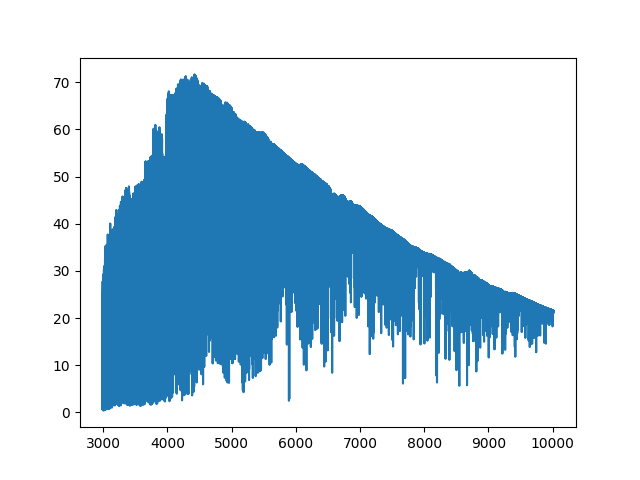

In [6]:
pumping = {}
dist_to_sun = ephemeris['mean_r_au']  # in AU
print(dist_to_sun)
file['Pumping'] = file['KURUCZ_SHIFTED'] * ( 1/ dist_to_sun)**2

#full kurucz pumping, needed to include A-X 
pumping_df = pd.read_csv(f'Pumping_files/pumping_{night}.txt', sep='\t')
pumping_df['FLUX'] = pumping_df['FLUX'] * (1 / dist_to_sun)**2
pumping[night] = pumping_df

plt.figure()
plt.plot(pumping_df['WAVE'], pumping_df['FLUX'])
plt.show()

Now lets create this table for the lines 

# lsf modeling to improve fit and pumping of the sun

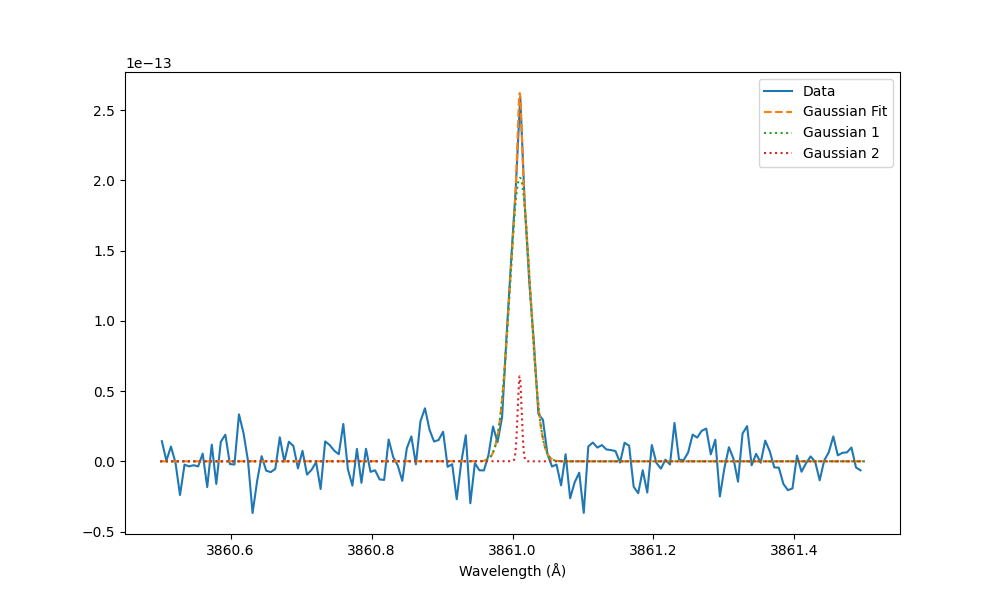

Fitted Gaussians:
Gaussian 1: Amplitude = 2.0174155619013171e-13, Mean = 3861.010562048752, Stddev = 0.014512931917067477
Gaussian 2: Amplitude = 6.046495313905029e-14, Mean = 3861.0101288489846, Stddev = 0.0028331164384297115


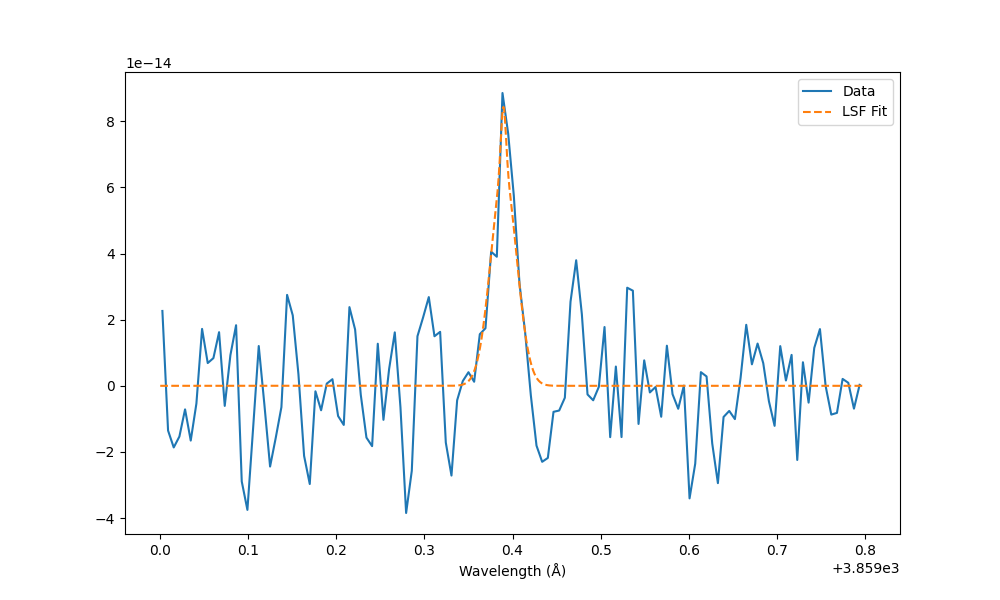

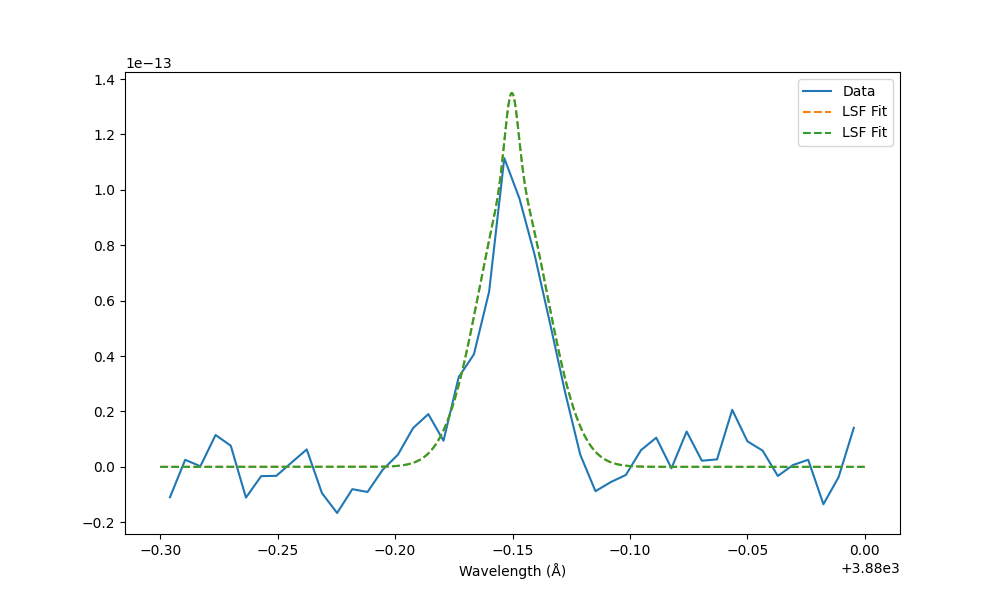

In [7]:
mask = (file['WAVE'] >= 3860.5) & (file['WAVE'] <= 3861.5)
x_fit = file['WAVE'][mask]
y_fit = file['FLUX_STACK'][mask] - file['CONTINUUM'][mask]
y_err = file['ERR_STACK'][mask]

# lets fit first a gaussian
model = models.Gaussian1D(amplitude=1e-13, mean=3861.0, stddev=0.02)
model += models.Gaussian1D(amplitude=1e-13, mean=3861, stddev=0.01)
fit = fitting.LevMarLSQFitter()
g_init = model
g_fit = fit(g_init, x_fit, y_fit, weights=1/y_err)

x_mod = np.linspace(3860.5, 3861.5, 10000)
plt.figure(figsize=(10, 6))
plt.plot(x_fit, y_fit, label='Data')
plt.plot(x_mod, g_fit(x_mod), label='Gaussian Fit', linestyle='--')
#plot gaussians separately
plt.plot(x_mod, models.Gaussian1D(amplitude=g_fit.amplitude_0.value, mean=g_fit.mean_0.value, stddev=g_fit.stddev_0.value)(x_mod), label='Gaussian 1', linestyle=':')
plt.plot(x_mod, models.Gaussian1D(amplitude=g_fit.amplitude_1.value, mean=g_fit.mean_1.value, stddev=g_fit.stddev_1.value)(x_mod), label='Gaussian 2', linestyle=':')
plt.xlabel('Wavelength (Å)')
plt.legend()
plt.show()

print(f"Fitted Gaussians:")
print(f"Gaussian 1: Amplitude = {g_fit.amplitude_0.value}, Mean = {g_fit.mean_0.value}, Stddev = {g_fit.stddev_0.value}")
print(f"Gaussian 2: Amplitude = {g_fit.amplitude_1.value}, Mean = {g_fit.mean_1.value}, Stddev = {g_fit.stddev_1.value}")

# 2) Normalize g_fit once around its own region
x_lsf = np.linspace(3860.5, 3861.5, 10000)
norm = np.trapezoid(g_fit(x_lsf), x_lsf)

# 3) Define a reference center for the LSF (e.g. amplitude-weighted mean)
ref_center = (
    g_fit.amplitude_0.value * g_fit.mean_0.value +
    g_fit.amplitude_1.value * g_fit.mean_1.value
) / (g_fit.amplitude_0.value + g_fit.amplitude_1.value)

# 4) LSF model: shift the fitted profile so that its peak moves to `center`
@models.custom_model
def lsf_model(x, amplitude=1.0, center=ref_center):
    # shift x so that when x=center we sample g_fit at ref_center
    return amplitude * g_fit(x - center + ref_center) / norm


mask2 = (
    (file['WAVE'] >= 3859.0) & (file['WAVE'] <= 3859.8) &
    np.isfinite(file['FLUX_STACK']) &
    np.isfinite(file['ERR_STACK']) &
    (file['ERR_STACK'] > 0)
)

x_fit2 = file['WAVE'][mask2]
y_fit2 = file['FLUX_STACK'][mask2] - file['CONTINUUM'][mask2]
y_err2 = file['ERR_STACK'][mask2]

fit2 = fitting.LevMarLSQFitter()

# Initial guesses:
amp0 = 2.5e-15 # absorption -> negative; adjust sign if emission
cen0 = 3859.39

m0 = lsf_model(amplitude=amp0, center=cen0)
lsf_fit = fit2(m0, x_fit2, y_fit2, weights=1.0/y_err2)

x_mod = np.linspace(3859.0, 3859.8, 2000)

plt.figure(figsize=(10, 6))
plt.plot(x_fit2, y_fit2, label='Data')
plt.plot(x_mod, lsf_fit(x_mod), label='LSF Fit', linestyle='--')
plt.xlabel('Wavelength (Å)')
plt.legend()
plt.show()


#lets try a third window lsf fitting(3879.7, 3880)
mask = (file['WAVE'] >= 3879.7) & (file['WAVE'] <= 3880)
x_fit = file['WAVE'][mask]
y_fit = file['FLUX_STACK'][mask] - file['CONTINUUM'][mask]
y_err = file['ERR_STACK'][mask]
amp0 = 4e-15 # absorption -> negative; adjust sign if emission
cen0 = 3879.85
m1 = lsf_model(amplitude=amp0, center=cen0)
lsf_fit2 = fit2(m1, x_fit, y_fit, weights=1.0/y_err)
x_mod = np.linspace(3879.7, 3880, 2000)
plt.figure(figsize=(10, 6))
plt.plot(x_fit, y_fit, label='Data')
plt.plot(x_mod, m1(x_mod), label='LSF Fit', linestyle='--')
plt.plot(x_mod, lsf_fit2(x_mod), label='LSF Fit', linestyle='--')
plt.xlabel('Wavelength (Å)')
plt.legend()
plt.show()

# LSF as a function of Δλ = λ - λ0
def lsf_delta(delta_lambda):
    """
    Normalized LSF as function of offset from line center.
    Integral over delta_lambda is 1.
    """
    # evaluate g_fit at ref_center + Δλ and normalize
    return g_fit(ref_center + delta_lambda) / norm

### G-factors

[warn] Found Q-branch labels in B–X subset; check 'Des' parsing.
Counts after filter: B–X(0,0) = 320 | A–X(1,0) = 450
[diag] N levels: 882 | M finite: True
[collisions] Ground levels found: 278
[collisions] Added links: 1593; Q=1.000e-05 s^-1, T=300.0 K
[diag] n finite: True sum: 1.0
[diag] N levels: 882 | M finite: True
[collisions] Ground levels found: 278
[collisions] Added links: 1593; Q=1.000e-01 s^-1, T=300.0 K
[diag] n finite: True sum: 1.0


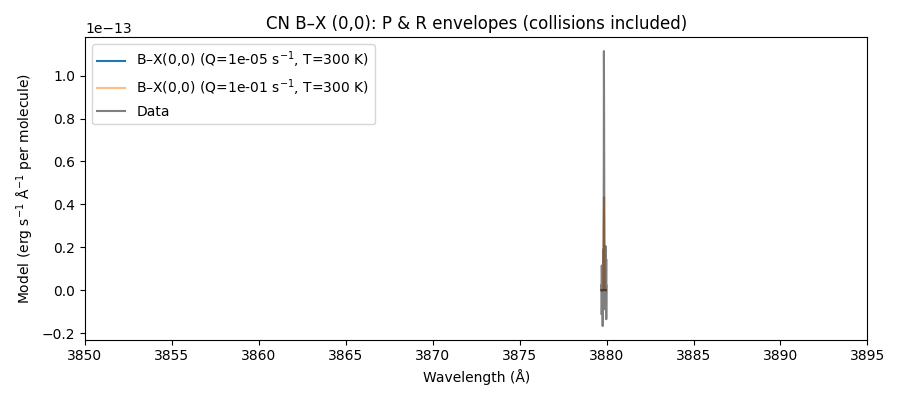

In [15]:
# -*- coding: utf-8 -*-
"""
CN fluorescence with Brooke et al. line lists:
- Filter to B–X(0–0) and A–X(1–0)
- Build radiative rate matrix (photon-occupation nbar)
- Add X-state rotational collisions (Manfroid-style)
- Solve and synthesize separate spectra
"""

# ----------------------------- I/O: Brooke parser ------------------------------

def load_cn_linelist(path_or_text: str) -> pd.DataFrame:
    colspecs = [
        (0,1), (2,3), (4,6), (7,9), (10,15), (16,21), (22,23), (24,25),
        (26,27), (28,29), (30,33), (34,37), (38,49), (50,60), (61,69),
        (70,80), (81,93), (94,106), (107,118)
    ]
    names = ["eS'", "eS''", "v'", "v''", "J'", "J''", "F'", "F''", "p'", "p''",
             "N'", "N''", "Obs", "Cal", "Res", "E''", "A", "f", "Des"]

    # read text
    if '\n' in path_or_text or path_or_text.strip().startswith("Title:"):
        text = path_or_text
    else:
        with open(path_or_text, "r", encoding="utf-8") as f:
            text = f.read()

    # keep fixed-width rows that start with state letters
    data_lines = [ln for ln in text.splitlines()
                  if len(ln) > 2 and ln[0] in "ABX" and ln[1].isspace() and ln[2] in "ABX"]

    df = pd.read_fwf(io.StringIO("\n".join(data_lines)),
                     colspecs=colspecs, names=names)

    # numeric conversions
    num_cols = ["v'", "v''", "J'", "J''", "F'", "F''", "N'", "N''", "Obs", "Cal", "Res", "E''", "A", "f"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    for c in ["eS'", "eS''", "p'", "p''", "Des", "N'"]:
        df[c] = df[c].astype(str).str.strip()

    # wavelengths from wavenumber (Cal/Obs in cm^-1) → Å
    wn_cal = df["Cal"].to_numpy(float)
    wn_obs = df["Obs"].to_numpy(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        lam_cal_A  = 1e8 / wn_cal
        lam_obs_A  = 1e8 / wn_obs

    df["lambda_vac_A_from_Cal"] = lam_cal_A
    df["lambda_vac_A_from_Obs"] = lam_obs_A
    return df

# ----------------------- Filtering & labeling helpers --------------------------

def filter_AX_BX(df_all: pd.DataFrame,
                 use_observed_only=False,
                 lambda_min_A=2990.0010, lambda_max_A=10009.9980,
                 use_obs_wavelength=False, A_min=1e4) -> pd.DataFrame:
    """Keep B–X(0,0) + A–X(1,0) inside wavelength window (Å)."""
    df = df_all.copy()
    lam_col = "lambda_vac_A_from_Obs" if use_obs_wavelength else "lambda_vac_A_from_Cal"

    # subset: emitter in A or B, lower X
    df = df[(df["eS'"].isin(["A","B"])) & (df["eS''"]=="X")]

    # masks
    m_B00 = (df["eS'"]=="B") & (df["v'"]==0) & (df["v''"]==0)
    m_A10 = (df["eS'"]=="A") & (df["v'"]-df["v''"]==1)

    df = df[m_B00 | m_A10]

    # wavelength window
    df = df[(df[lam_col] >= lambda_min_A) & (df[lam_col] <= lambda_max_A)]

    if use_observed_only:
        df = df[np.isfinite(df["Obs"])]

    # sanity: no Q in B–X
    if df[(df["eS'"]=="B") & df["Des"].str.contains('Q', na=False)].shape[0] > 0:
        print("[warn] Found Q-branch labels in B–X subset; check 'Des' parsing.")
    # keep stroongest lines A>1e4
    is_A_strong =  df["A"] > A_min
    df = df[is_A_strong]
    return df

#keys for each state (needed for the summatory)
def make_manifold(es, v):
    es = str(es).strip().upper()
    return f"Ground X v={int(v)}" if es.startswith('X') else f"{es} v={int(v)}"

#also needed for the summatory as a par of the state
def make_sym(F, p, use_omega=False, es=None):
    ptag = str(p).strip().lower()[:1] if p not in (None, "") else "?"
    try:
        Fint = int(F)
    except Exception:
        Fint = F
    if use_omega and str(es).strip().upper().startswith("A"):
        comp = "Ω3/2" if Fint == 1 else "Ω1/2"   # Brooke note for A 2Π
        return f"{comp}_{ptag}"
    return f"F{Fint}_{ptag}"

# ------------------------------ Pumping field ----------------------------------
def attach_pumping_and_labels(df: pd.DataFrame,
                              wave_AA: np.ndarray,
                              F_lambda_erg_s_cm2_AA: np.ndarray,
                              use_obs_wavelength=False,
                              use_omega_labels=False) -> Table:
    """Interpolate Fλ(Å) to each line, compute Jν, add solver labels, return Table."""
    lam_col = "lambda_vac_A_from_Obs" if use_obs_wavelength else "lambda_vac_A_from_Cal"
    lines = Table.from_pandas(df.copy())

    lam = (np.asarray(lines[lam_col], float) * u.AA)
    lines["Wave_vac_AA"]  = lam.to_value(u.AA)
    lines["Frequency_Hz"] = (const.c / lam).to(u.Hz)

    # Fλ at comet
    F_lambda = np.asarray(F_lambda_erg_s_cm2_AA, float) * (u.erg / (u.s * u.cm**2 * u.AA))
    lam_grid = np.asarray(wave_AA, float)
    F_interp = np.interp(lines["Wave_vac_AA"], lam_grid, F_lambda.value) * F_lambda.unit
    lines["F_lambda_at_comet_erg_s_cm2_AA"] = F_interp

    # Fλ → Fν → Jν = Fν / (4π)
    F_nu = F_interp.to(u.erg / (u.s * u.cm**2 * u.Hz), equivalencies=u.spectral_density(lam))
    J_nu = (F_nu / (4*np.pi)) * (1/u.sr)  # sr explicit but dimensionless in SI
    lines["J_nu_erg_cm2_s_Hz_sr"] = J_nu.to(u.erg / (u.cm**2 * u.s * u.Hz * u.sr))

    # labels
    lines["J_prime"]       = lines["J'"]
    lines["J_doubleprime"] = lines["J''"]
    lines["Upper_Manifold"] = [make_manifold(es, v) for es, v in zip(lines["eS'"], lines["v'"])]
    lines["Lower_Manifold"] = [make_manifold(es, v) for es, v in zip(lines["eS''"], lines["v''"])]
    lines["Sym_prime"]       = [make_sym(F, p, use_omega_labels, es=es) for F, p, es in zip(lines["F'"], lines["p'"], lines["eS'"])]
    lines["Sym_doubleprime"] = [make_sym(F, p, use_omega_labels, es=es) for F, p, es in zip(lines["F''"], lines["p''"], lines["eS''"])]
    return lines

# --------------------------- Radiative rate matrix ------------------------------

def build_rate_matrix_nbar(lines: Table, include_stim_emission=False, verbose=True):
    """Photon-occupation form: nbar = (c^2/(2 h ν^3)) * Jν(SI)."""
    lines_out = lines.copy()
    nu  = lines_out["Frequency_Hz"].to(u.Hz)
    Aul = (lines_out["A"] * (1/u.s)).to(1/u.s)

    Jnu_cgs = lines_out["J_nu_erg_cm2_s_Hz_sr"].to(u.erg / (u.cm**2 * u.s * u.Hz * u.sr))
    Jnu_SI  = Jnu_cgs.to(u.W / (u.m**2 * u.Hz * u.sr))

    Jp  = np.asarray(lines_out["J_prime"],       float)
    Jpp = np.asarray(lines_out["J_doubleprime"], float)
    gu, gl = 2.0*Jp + 1.0, 2.0*Jpp + 1.0

    nbar = (const.c**2 / (2.0*const.h*nu**3) * Jnu_SI).decompose().value

    Aul_v = Aul.to_value(1/u.s)
    R_lu = (gu/gl) * Aul_v * nbar
    R_ul = Aul_v + (Aul_v * nbar if include_stim_emission else 0.0)

    # level indices
    up_man = np.asarray(lines_out["Upper_Manifold"], str)
    up_sym = np.asarray(lines_out["Sym_prime"], str)
    lo_man = np.asarray(lines_out["Lower_Manifold"], str)
    lo_sym = np.asarray(lines_out["Sym_doubleprime"], str)

    all_levels = {}
    upper_idx, lower_idx = [], []
    for i in range(len(lines_out)):
        ku = (up_man[i], float(Jp[i]),  up_sym[i])
        kl = (lo_man[i], float(Jpp[i]), lo_sym[i])
        if ku not in all_levels: all_levels[ku] = len(all_levels)
        if kl not in all_levels: all_levels[kl] = len(all_levels)
        upper_idx.append(all_levels[ku]); lower_idx.append(all_levels[kl])
    idx_to_level = {v: k for k, v in all_levels.items()}
    n_levels = len(idx_to_level)

    # assemble M
    M = np.zeros((n_levels, n_levels), float)
    def add_rate(dest, src, rate):
        if not np.isfinite(rate) or rate == 0.0: return
        M[src, src] -= rate
        M[dest, src] += rate

    for iu, il, rlu, rul in zip(upper_idx, lower_idx, R_lu, R_ul):
        add_rate(iu, il, float(rlu))  # absorption: l→u
        add_rate(il, iu, float(rul))  # emission:   u→l

    # stash
    lines_out["__nu_Hz"]      = nu.to_value(u.Hz)
    lines_out["__R_lu"]       = R_lu
    lines_out["__R_ul"]       = R_ul
    lines_out["__upper_idx"]  = np.asarray(upper_idx, int)
    lines_out["__lower_idx"]  = np.asarray(lower_idx, int)

    if verbose:
        print("[diag] N levels:", n_levels, "| M finite:", np.isfinite(M).all())
    return M, idx_to_level, lines_out

# ------------------------- X-state rotational collisions ------------------------

def add_cn_collisions_to_M(M, lines_with_rates, idx_to_level,
                           Q=1e-3, T=300.0, include_deltaJ0=True, verbose=True):
    """
    Rotational collisions among X-state (Ground) levels:
      - constant downward C_{u->l} = Q (s^-1) for |ΔJ|=1; optionally ΔJ=0 across e/f
      - upward by detailed balance: g_l C_{l->u} = g_u C_{u->l} exp(-(E_u - E_l)/kT)
      - energies from E'' (cm^-1), relative to v''=0 origin (OK: only ΔE matters)
    """
    kT = (const.k_B * (T * u.K)).to(u.erg).value
    if Q < 0: Q = 0.0

    lower_idx = np.asarray(lines_with_rates["__lower_idx"], int)
    Jpp       = np.asarray(lines_with_rates["J_doubleprime"], float)
    Elower    = np.asarray(lines_with_rates["E''"], float)  # cm^-1

    # collect per-level energies (median)
    E_level_cm = {}
    J_level, sym_level = {}, {}
    for i, idx in enumerate(lower_idx):
        man, Jlab, sym = idx_to_level[idx]
        if str(man).lower().startswith("ground"):
            E_level_cm.setdefault(idx, []).append(Elower[i])
            J_level[idx]   = float(Jpp[i])
            sym_level[idx] = str(sym)
    ground_ids = sorted(E_level_cm.keys())
    if verbose: print(f"[collisions] Ground levels found: {len(ground_ids)}")
    if not ground_ids: 
        if verbose: print("[collisions] None found; skipping.")
        return M

    Eerg, gdeg = {}, {}
    for idx in ground_ids:
        if len(E_level_cm[idx]) == 0: continue
        Ecm  = np.median(np.asarray(E_level_cm[idx], float)) * (1/u.cm)
        Eerg[idx] = (const.h * const.c * Ecm).to(u.erg).value
        gdeg[idx] = 2.0 * J_level[idx] + 1.0

    # neighbor map by ΔJ
    ground_sorted = sorted(ground_ids, key=lambda i: (J_level[i], sym_level[i]))
    pairs_done = set()

    def add_pair(iu, il, C_down):
        if C_down <= 0: return
        gu, gl = gdeg[iu], gdeg[il]
        dE = Eerg[iu] - Eerg[il]  # erg
        Cup = (gu/gl) * C_down * np.exp(-dE / kT)

        M[iu, iu] -= C_down
        M[il, iu] += C_down
        if np.isfinite(Cup) and Cup > 0:
            M[il, il] -= Cup
            M[iu, il] += Cup
        return M
    for i in range(len(ground_sorted)):
        i_idx = ground_sorted[i]
        Ji, si = J_level[i_idx], sym_level[i_idx]
        for j in range(i+1, len(ground_sorted)):
            j_idx = ground_sorted[j]
            Jj, sj = J_level[j_idx], sym_level[j_idx]
            dJ = abs(Ji - Jj)
            allow = (dJ == 1) or (include_deltaJ0 and (dJ == 0) and (si != sj))
            if not allow: 
                continue
            # assign higher/lower by energy
            iu, il = (j_idx, i_idx) if Eerg[j_idx] > Eerg[i_idx] else (i_idx, j_idx)
            key = (min(iu, il), max(iu, il))
            if key in pairs_done: 
                continue
            pairs_done.add(key)
            M = add_pair(iu, il, Q)

    if verbose:
        print(f"[collisions] Added links: {len(pairs_done)}; Q={Q:.3e} s^-1, T={T:.1f} K")
    return M

# --------------------------------- Solver & g ----------------------------------

def solve_with_normalization(M, verbose=True):
    n_levels = M.shape[0]
    A = M.copy()
    b = np.zeros(n_levels, float)
    A[-1, :] = 1.0
    b[-1] = 1.0
    try:
        n = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        if verbose: print("[solve] singular; using tiny diagonal regularization")
        eps = 1e-12
        A_reg = M + np.eye(n_levels) * eps
        A_reg[-1, :] = 1.0
        n = np.linalg.lstsq(A_reg, b, rcond=None)[0]
    n = np.nan_to_num(n, nan=0.0, posinf=0.0, neginf=0.0)
    n[n < 0] = 0.0
    s = n.sum()
    n = (n / s) if s > 0 else np.eye(1, n_levels, 0).ravel()
    if verbose:
        print("[diag] n finite:", np.isfinite(n).all(), "sum:", n.sum())
    return n

def g_factors(lines_with_rates: Table, n):
    nu  = np.asarray(lines_with_rates["__nu_Hz"], float)
    Aul = np.asarray(lines_with_rates["A"], float)
    ui  = np.asarray(lines_with_rates["__upper_idx"], int)
    nu  = np.nan_to_num(nu,  0.0, 0.0, 0.0)
    Aul = np.nan_to_num(Aul, 0.0, 0.0, 0.0)
    n_u = n[ui]
    g_ph = n_u * Aul
    g_en = (const.h.cgs.value * nu) * g_ph
    g_ph = np.nan_to_num(g_ph, 0.0, 0.0, 0.0)
    g_en = np.nan_to_num(g_en, 0.0, 0.0, 0.0)
    return g_ph, g_en, float(g_ph.sum()), float(g_en.sum())

# ------------------------------ Spectrum builder --------------------------------
def synth_spectrum_from_lines(
    df_lines, g_line_energy=None, g_line_phot=None,
    fwhm_A=1.0, dlam_A=0.05, lam_min=None, lam_max=None,
    dlam_shift=0.0, lam_col="Wave_vac_AA",
    N_col_cm2=None, Omega_sr=1.846e-11, grid=None
):
    """
    Build a spectrum from per-line g-factors (Gaussian LSF),
    scaled by a COLUMN DENSITY only.

    Inputs
    ------
    df_lines : Astropy Table with columns:
        lam_col (Å), and either '__nu_Hz' or 'Frequency_Hz' if g_line_phot is used
    g_line_energy : array, per-line energy g-factor [erg s^-1 molecule^-1]
    g_line_phot   : array, per-line photon g-factor [photons s^-1 molecule^-1]
    fwhm_A        : float, Gaussian FWHM in Å
    dlam_A        : float, wavelength step for output grid in Å
    lam_min, lam_max : float, wavelength limits (Å). If None, auto from lines.
    dlam_shift    : float, small wavelength shift (Å)
    lam_col       : str, name of wavelength column in Å (default 'Wave_vac_AA')
    N_col_cm2     : float, COLUMN DENSITY [cm^-2] (required to scale physically)
    Omega_sr      : float or None, aperture solid angle [sr].
                    If None -> return surface brightness (per sr).
                    If given -> return flux (integrated over aperture).

    Returns
    -------
    grid : ndarray [Å]
    y    : ndarray
           If Omega_sr is None: surface brightness I_λ [erg s^-1 cm^-2 sr^-1 Å^-1]
           Else: flux F_λ = I_λ * Ω [erg s^-1 cm^-2 Å^-1]
    """
    import numpy as np
    from astropy import constants as const

    if N_col_cm2 is None:
        raise ValueError("N_col_cm2 (column density in cm^-2) is required.")

    if lam_col not in df_lines.colnames:
        raise ValueError(f"Need '{lam_col}' in df_lines.")

    # wavelengths (Å) and per-line power (erg s^-1 per molecule)
    lam = np.asarray(df_lines[lam_col], float) + dlam_shift

    if g_line_energy is not None:
        I_line = np.asarray(g_line_energy, float)
    elif g_line_phot is not None:
        # convert photons/s to erg/s using line frequency
        if "__nu_Hz" in df_lines.colnames:
            nu = np.asarray(df_lines["__nu_Hz"], float)
        else:
            nu = np.asarray(df_lines["Frequency_Hz"], float)
        I_line = (const.h.cgs.value * nu) * np.asarray(g_line_phot, float)
    else:
        raise ValueError("Provide g_line_energy or g_line_phot.")

    # keep finite, positive
    m = np.isfinite(lam) & np.isfinite(I_line) & (I_line > 0)
    lam, I_line = lam[m], I_line[m]
    if lam.size == 0:
        return np.array([]), np.array([])

    # output grid
    if lam_min is None: lam_min = lam.min() - 1.0
    if lam_max is None: lam_max = lam.max() + 1.0
    
    if grid is None:
        grid = np.arange(lam_min, lam_max, dlam_A)

    # Gaussian LSF normalized to ∫ G dλ = 1
    sigma = fwhm_A / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    norm  = 1.0 / (sigma * np.sqrt(2.0 * np.pi))

    # per-molecule spectrum: erg s^-1 Å^-1 molecule^-1
    spec_per_mol = np.zeros_like(grid)
    for lam0, area in zip(lam, I_line):
        spec_per_mol += area * norm * np.exp(-0.5 * ((grid - lam0) / sigma) ** 2)

    # column-density scaling (optically thin, isotropic): divide by 4π
    # I_λ = (N_col / 4π) * spec_per_mol   → erg s^-1 cm^-2 sr^-1 Å^-1
    fourpi = 4.0 * np.pi
    I_lambda = (N_col_cm2 / fourpi) * spec_per_mol

    # if aperture solid angle given, return flux; else surface brightness
    if Omega_sr is not None:
        F_lambda = I_lambda * Omega_sr   # erg s^-1 cm^-2 Å^-1
        return grid, F_lambda
    else:
        return grid, I_lambda

# --------------------------------- Main demo ------------------------------------

if __name__ == "__main__":
    # ==== 1) Load Brooke table ====
    brooke_path = "CN_lines/12C14N.txt"  # <-- set your path
    df_all = load_cn_linelist(brooke_path)
    # ==== 2) Filter to B–X(0,0) + A–X(1,0) ====
    use_obs_wave = False      # True -> use Obs wavelengths
    use_obs_only = False      # True -> drop lines with blank Obs
    df = filter_AX_BX(df_all,
                      use_observed_only=use_obs_only,
                      lambda_min_A=2990.0010, lambda_max_A=10009.9980,
                      use_obs_wavelength=use_obs_wave)
    print("Counts after filter:",
          "B–X(0,0) =", df[(df["eS'"]=='B') & (df["v'"]==0) & (df["v''"]==0)].shape[0],
          "| A–X(1,0) =", df[(df["eS'"]=='A') & (df["v'"]==1) & (df["v''"]==0)].shape[0])

    # ==== 3) Pumping spectrum (Å, erg s^-1 cm^-2 Å^-1) ====
    # Replace with your real arrays:
 # flat irradiance just for demo
    pump_wave = pumping['20250924']['WAVE']
    pump_flux = pumping['20250924']['FLUX']
    # ==== 4) Attach pumping, labels; build radiative matrix ====
    lines = attach_pumping_and_labels(df, pump_wave, pump_flux,
                                      use_obs_wavelength=False,
                                      use_omega_labels=False)
    M, idx2lvl, lines_out = build_rate_matrix_nbar(lines, include_stim_emission=False, verbose=True)

    # ==== 5) Add X-state rotational collisions ====
    Q_COLL = 1e-5  # s^-1  (try 1e-5 .. 1e-3)
    T_COLL = 300.0  # K
    M = add_cn_collisions_to_M(M, lines_out, idx2lvl, Q=Q_COLL, T=T_COLL, include_deltaJ0=True, verbose=True)

    # ==== 6) Solve populations ====
    n = solve_with_normalization(M, verbose=True)

    # ==== 7) g-factors & spectra ====
    g_ph, g_en, gtot_ph, gtot_en = g_factors(lines_out, n)

    is_B00 = (lines_out["eS'"]=='B') & (lines_out["eS''"]=='X') & (lines_out["v'"]==0) & (lines_out["v''"]==0)
    is_A10 = (lines_out["eS'"]=='A') & (lines_out["eS''"]=='X') & (lines_out["v'"]==1) & (lines_out["v''"]==0)

    # B–X(0,0): include bandhead ~3883.4 Å
    grid_B, spec_B = synth_spectrum_from_lines(lines_out[is_B00], g_line_energy=g_en[is_B00],
                                               fwhm_A=0.02, dlam_A=0.05,
                                               lam_min=x_fit.min(), lam_max=x_fit.max(),
                                               N_col_cm2=5e11)

    # ==== 8) Plot ====
    plt.figure(figsize=(9,4))
    if grid_B.size:
        plt.plot(grid_B, spec_B, label=f"B–X(0,0) (Q={Q_COLL:.0e} s$^{{-1}}$, T={T_COLL:.0f} K)")
    plt.xlim(3850, 3895); plt.xlabel("Wavelength (Å)")
    plt.ylabel("Model (erg s$^{-1}$ Å$^{-1}$ per molecule)")
    plt.title("CN B–X (0,0): P & R envelopes (collisions included)")

    pump_wave = pumping['20250924']['WAVE']
    pump_flux = pumping['20250924']['FLUX']
    # ==== 4) Attach pumping, labels; build radiative matrix ====
    lines = attach_pumping_and_labels(df, pump_wave, pump_flux,
                                      use_obs_wavelength=False,
                                      use_omega_labels=False)


    M, idx2lvl, lines_out = build_rate_matrix_nbar(lines, include_stim_emission=False, verbose=True)

    # ==== 5) Add X-state rotational collisions ====
    Q_COLL = 1e-1  # s^-1  (try 1e-5 .. 1e-3)
    T_COLL = 300  # K
    M = add_cn_collisions_to_M(M, lines_out, idx2lvl, Q=Q_COLL, T=T_COLL, include_deltaJ0=True, verbose=True)

    # ==== 6) Solve populations ====
    n = solve_with_normalization(M, verbose=True)

    # ==== 7) g-factors & spectra ====
    g_ph, g_en, gtot_ph, gtot_en = g_factors(lines_out, n)

    is_B00 = (lines_out["eS'"]=='B') & (lines_out["eS''"]=='X') & (lines_out["v'"]==0) & (lines_out["v''"]==0)
    is_A10 = (lines_out["eS'"]=='A') & (lines_out["eS''"]=='X') & (lines_out["v'"]==1) & (lines_out["v''"]==0)

    # B–X(0,0): include bandhead ~3883.4 Å
    grid_B, spec_B = synth_spectrum_from_lines(lines_out[is_B00], g_line_energy=g_en[is_B00],
                                               fwhm_A=0.02, dlam_A=0.05,
                                               lam_min=x_fit.min(), lam_max=x_fit.max(),
                                               N_col_cm2=5e11)

    plt.plot(grid_B, spec_B, label=f"B–X(0,0) (Q={Q_COLL:.0e} s$^{{-1}}$, T={T_COLL:.0f} K)", alpha=0.5)
    plt.plot(x_fit, y_fit, label='Data', color='black', alpha=0.5)

    plt.legend(); plt.tight_layout()
    plt.show()


# Now lets fit:

You provided an LSF so that will be used
[warn] Found Q-branch labels in B–X subset; check 'Des' parsing.
Number of iterations: 16000


Sampling:   0%|          | 0/500 [00:00<?, ?step/s]

*** Done Fitting... ***
##################################################
*** Best fit no pruning ***
logN : 11.566240550100016
logQ : -0.613165595499491
T : 257.5946984576303
v_shift_kms : 0.5511097922775098


/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_26200/2665093128.py:505: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(min(y),max(y))


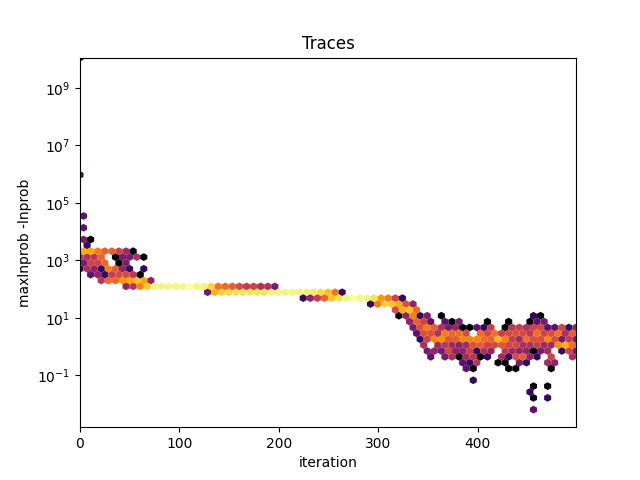

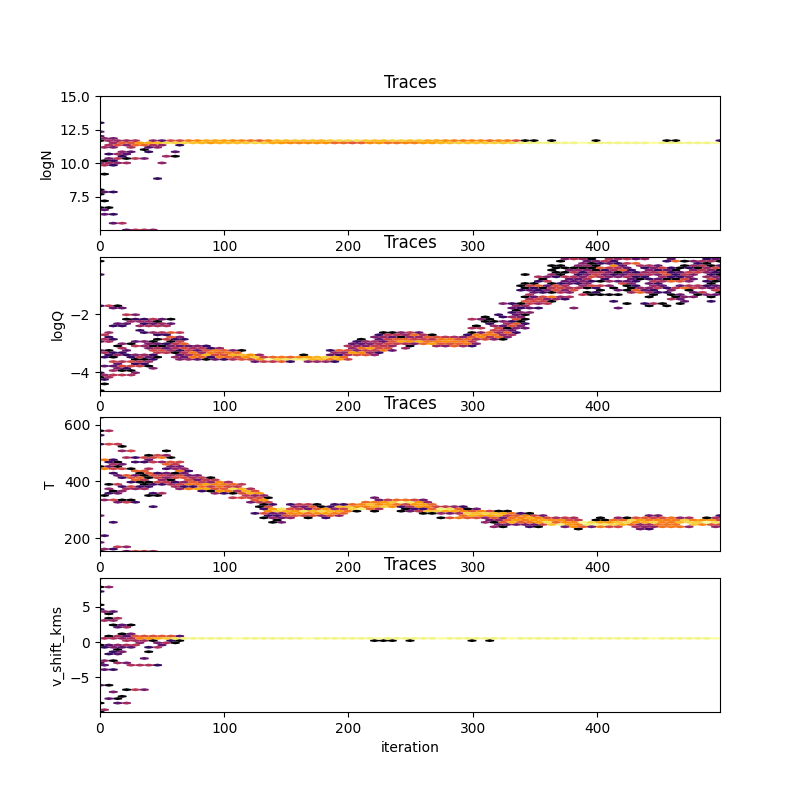

##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.40925
##################################################
*** Pruning... ***
2.785291764565045 12.071220788421705 9.28592902385666
2.168469333133544 6.453831088225656 4.285361755092112
1.9462011527793948 3.618823503553484 1.6726223507740894
1.9379215290828142 3.574718443725064 1.6367969146422499
1.9379215290828142 3.56012431662474 1.6222027875419256
1.796383813052671 2.550518588429082 0.7541347753764112
1.7431961744878208 2.1328995248512728 0.38970335036345194
1.6577615074056666 1.9380594657032086 0.280297958297542
1.5533093985723099 1.7146340265137991 0.16132462794148927
1.4771128912980203 1.5171361322431154 0.04002324094509513
logN: 11.5635 +/- 0.0077 [11.55492861 11.56346692 11.57041127]
logQ: -0.7381 +/- 0.4163 [-1.17355866 -0.73810397 -0.34089535]
T: 254.7861 +/- 7.7553 [248.38664323 254.78609325 263.89732973]
v_shift_kms: 0.5639 +/- 0.0237 [0.54246039 0.56387215 0.58996027]


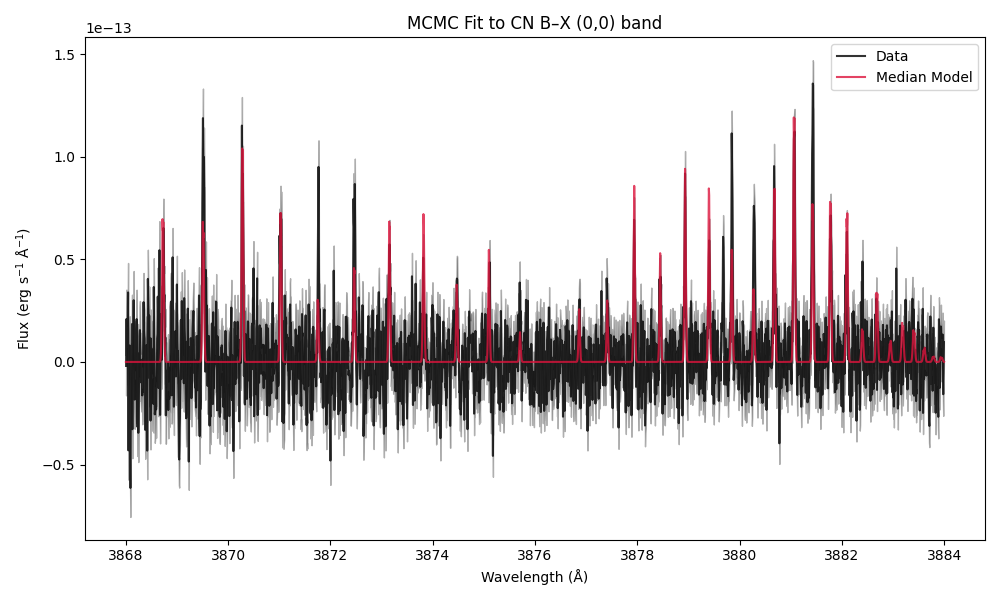

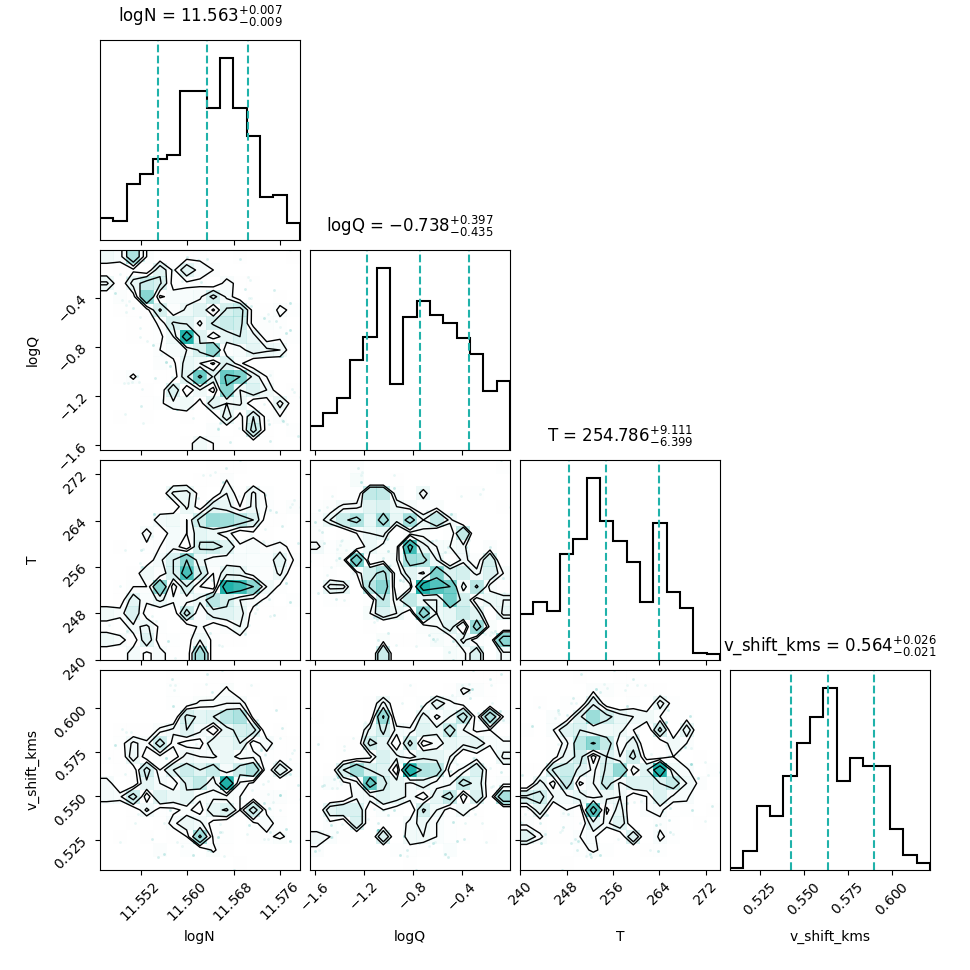

In [ ]:
import numpy as np

def precompute_cn_collision_scaffold(lines_out, idx_to_level):
    """Return arrays to apply X-state rotational collisions quickly."""
    lower_idx = np.asarray(lines_out['__lower_idx'], int)
    Jpp       = np.asarray(lines_out['J_doubleprime'], float)
    Elower_cm = np.asarray(lines_out["E''"], float)  # cm^-1

    # collect unique Ground levels properties
    E_level_cm = {}
    J_level, sym_level = {}, {}
    for i, idx in enumerate(lower_idx):
        man, Jlab, sym = idx_to_level[idx]
        if str(man).lower().startswith("ground"):
            E_level_cm.setdefault(idx, []).append(Elower_cm[i])
            J_level[idx]   = float(Jpp[i])
            sym_level[idx] = str(sym)
    ground_ids = sorted(E_level_cm.keys())
    if not ground_ids:
        return dict(iu=np.array([],int), il=np.array([],int),
                    gu=np.array([]), gl=np.array([]), dE=np.array([]))
    # finalize energies/degeneracies
    from astropy import constants as const, units as u
    Eerg, gdeg = {}, {}
    for idx in ground_ids:
        Ecm  = np.median(np.asarray(E_level_cm[idx], float)) * (1/u.cm)
        Eerg[idx] = (const.h * const.c * Ecm).to(u.erg).value
        gdeg[idx] = 2.0 * J_level[idx] + 1.0
    # build allowed pairs (ΔJ=±1 and e↔f for ΔJ=0)
    ground_sorted = sorted(ground_ids, key=lambda i: (J_level[i], sym_level[i]))
    iu_list, il_list, gu_list, gl_list, dE_list = [], [], [], [], []
    seen = set()
    for a in range(len(ground_sorted)):
        ia = ground_sorted[a]
        Ja, sa = J_level[ia], sym_level[ia]
        for b in range(a+1, len(ground_sorted)):
            ib = ground_sorted[b]
            Jb, sb = J_level[ib], sym_level[ib]
            dJ = abs(Ja - Jb)
            allow = (dJ == 1) or ((dJ == 0) and (sa != sb))  # include ΔJ=0 parity mixing
            allow = True
            if not allow: 
                continue
            iu, il = (ib, ia) if Eerg[ib] > Eerg[ia] else (ia, ib)
            key = (min(iu, il), max(iu, il))
            if key in seen: 
                continue
            seen.add(key)
            iu_list.append(iu); il_list.append(il)
            gu_list.append(gdeg[iu]); gl_list.append(gdeg[il])
            dE_list.append(Eerg[iu] - Eerg[il])  # >0
            #I want to print the delta energy in cm-1 for checking
            delta = (Eerg[iu] - Eerg[il]) * u.erg
            delta = delta / (const.h * const.c)
            delta = delta.to(u.cm**-1)

    return dict(iu=np.asarray(iu_list,int), il=np.asarray(il_list,int),
                gu=np.asarray(gu_list,float), gl=np.asarray(gl_list,float),
                dE=np.asarray(dE_list,float))

def apply_collisions_inplace(M, scaffold, Q, T):
    """Modify M in place with Manfroid-style collisions for X-state."""
    if scaffold['iu'].size == 0 or Q <= 0: 
        return
    from astropy import constants as const, units as u
    kT = (const.k_B * (T * u.K)).to(u.erg).value
    iu = scaffold['iu']; il = scaffold['il']
    gu = scaffold['gu']; gl = scaffold['gl']; dE = scaffold['dE']
    Cdown = Q * np.ones_like(iu, dtype=float)
    Cup   = (gu/gl) * Cdown * np.exp(-dE / kT)
    # diagonal losses
    np.add.at(M, (iu, iu), -Cdown)
    np.add.at(M, (il, il), -Cup)
    # off-diagonal gains
    np.add.at(M, (il, iu),  Cdown)
    np.add.at(M, (iu, il),  Cup)
    return M

def convolve_with_lsf(pump_wave_A, J_lambda, lsf_delta, max_offset_A=1.0):
    """
    pump_wave_A : 1D array [Å], sorted, ~uniform
    J_lambda    : 1D array, same shape, mean intensity per Å (erg cm^-2 s^-1 Å^-1 sr^-1)
    lsf_delta   : normalized LSF(Δλ) with Δλ in Å
    """
    pump_wave_A = np.asarray(pump_wave_A, float)
    dlam = np.median(np.diff(pump_wave_A))

    nker = int(max_offset_A / dlam)
    offsets = np.arange(-nker, nker + 1) * dlam
    kernel = lsf_delta(offsets)
    kernel = np.where(np.isfinite(kernel), kernel, 0.0)
    if kernel.sum() <= 0:
        raise RuntimeError("LSF kernel has non-positive total weight.")
    kernel /= kernel.sum()  # discrete normalization

    J_lambda_conv = np.convolve(J_lambda, kernel, mode="same")
    return J_lambda_conv

def attach_J_with_lsf(lines, pump_wave_A, pump_I_lambda, lsf_delta):
    """
    lines          : table with Frequency_Hz column
    pump_wave_A    : Å grid of pumping field
    pump_I_lambda  : I_λ(λ) [erg cm^-2 s^-1 Å^-1 sr^-1]
    lsf_delta      : normalized LSF(Δλ) in Å
    """
    pump_wave_A = np.asarray(pump_wave_A, float)
    pump_I_lambda = np.asarray(pump_I_lambda, float)

    # 1) convolve I_lambda with LSF
    J_lambda_conv = convolve_with_lsf(pump_wave_A, pump_I_lambda, lsf_delta)

    # 2) for each line, get wavelength and sample convolved J_lambda
    nu = lines["Frequency_Hz"]
    lam = (const.c / nu.to(1/u.s)).to(u.AA).value  # Å

    J_line_lambda = np.interp(lam, pump_wave_A, J_lambda_conv,
                              left=0.0, right=0.0)  # safe extrapolation

    # 3) convert J_λ → J_ν at the line center:
    #    Jν = Jλ * (λ^2 / c), with λ in cm
    lam_cm = (lam * u.AA).to(u.cm)
    J_lambda_q = (J_line_lambda * u.erg / (u.cm**2 * u.s * u.AA * u.sr))
    J_lambda_cm = J_lambda_q.to(u.erg / (u.cm**2 * u.s * u.cm * u.sr))
    J_nu = (J_lambda_cm * (lam_cm**2 / const.c)).to(
        u.erg / (u.cm**2 * u.s * u.Hz * u.sr)
    )

    lines["J_nu_erg_cm2_s_Hz_sr"] = J_nu
    return lines

def build_rate_matrix_nbar(lines: Table, include_stim_emission=False, verbose=True):
    """Photon-occupation form: nbar = (c^2/(2 h ν^3)) * Jν(SI)."""
    lines_out = lines.copy()
    nu  = lines_out["Frequency_Hz"].to(u.Hz)
    Aul = (lines_out["A"] * (1/u.s)).to(1/u.s)

    Jnu_cgs = lines_out["J_nu_erg_cm2_s_Hz_sr"].to(u.erg / (u.cm**2 * u.s * u.Hz * u.sr))
    Jnu_SI  = Jnu_cgs.to(u.W / (u.m**2 * u.Hz * u.sr))

    Jp  = np.asarray(lines_out["J_prime"],       float)
    Jpp = np.asarray(lines_out["J_doubleprime"], float)
    gu, gl = 2.0*Jp + 1.0, 2.0*Jpp + 1.0

    nbar = (const.c**2 / (2.0*const.h*nu**3) * Jnu_SI).decompose().value

    Aul_v = Aul.to_value(1/u.s)
    R_lu = (gu/gl) * Aul_v * nbar
    R_ul = Aul_v + (Aul_v * nbar if include_stim_emission else 0.0)

    # level indices
    up_man = np.asarray(lines_out["Upper_Manifold"], str)
    up_sym = np.asarray(lines_out["Sym_prime"], str)
    lo_man = np.asarray(lines_out["Lower_Manifold"], str)
    lo_sym = np.asarray(lines_out["Sym_doubleprime"], str)

    all_levels = {}
    upper_idx, lower_idx = [], []
    for i in range(len(lines_out)):
        ku = (up_man[i], float(Jp[i]),  up_sym[i])
        kl = (lo_man[i], float(Jpp[i]), lo_sym[i])
        if ku not in all_levels: all_levels[ku] = len(all_levels)
        if kl not in all_levels: all_levels[kl] = len(all_levels)
        upper_idx.append(all_levels[ku]); lower_idx.append(all_levels[kl])
    idx_to_level = {v: k for k, v in all_levels.items()}
    n_levels = len(idx_to_level)

    # assemble M
    M = np.zeros((n_levels, n_levels), float)
    def add_rate(dest, src, rate):
        if not np.isfinite(rate) or rate == 0.0: return
        M[src, src] -= rate
        M[dest, src] += rate

    for iu, il, rlu, rul in zip(upper_idx, lower_idx, R_lu, R_ul):
        add_rate(iu, il, float(rlu))  # absorption: l→u
        add_rate(il, iu, float(rul))  # emission:   u→l

    # stash
    lines_out["__nu_Hz"]      = nu.to_value(u.Hz)
    lines_out["__R_lu"]       = R_lu
    lines_out["__R_ul"]       = R_ul
    lines_out["__upper_idx"]  = np.asarray(upper_idx, int)
    lines_out["__lower_idx"]  = np.asarray(lower_idx, int)

    if verbose:
        print("[diag] N levels:", n_levels, "| M finite:", np.isfinite(M).all())
    return M, idx_to_level, lines_out

def synth_spectrum_from_lines(
    df_lines,
    g_line_energy=None,
    g_line_phot=None,
    dlam_A=0.05,
    lam_min=None,
    lam_max=None,
    dlam_shift=0.0,
    v_shift_kms=None,
    lam_col="Wave_vac_AA",
    N_col_cm2=None,
    Omega_sr=None,
    grid=None,
    lsf=None,
):
    import numpy as np
    from astropy import constants as const

    if N_col_cm2 is None:
        raise ValueError("N_col_cm2 is required.")
    if lam_col not in df_lines.colnames:
        raise ValueError(f"Need '{lam_col}' in df_lines.")
    if lsf is None:
        raise ValueError("lsf must be provided.")

    lam_rest = np.asarray(df_lines[lam_col], float)

    if v_shift_kms is not None:
        c_kms = const.c.to("km/s").value
        lam = lam_rest * (1.0 + v_shift_kms / c_kms)
        if dlam_shift != 0.0:
            lam = lam + dlam_shift
    else:
        lam = lam_rest + dlam_shift

    if g_line_energy is not None:
        I_line = np.asarray(g_line_energy, float)
    elif g_line_phot is not None:
        if "__nu_Hz" in df_lines.colnames:
            nu = np.asarray(df_lines["__nu_Hz"], float)
        else:
            nu = np.asarray(df_lines["Frequency_Hz"], float)
        I_line = (const.h.cgs.value * nu) * np.asarray(g_line_phot, float)
    else:
        raise ValueError("Provide g_line_energy or g_line_phot.")

    m = np.isfinite(lam) & np.isfinite(I_line) & (I_line > 0)
    lam, I_line = lam[m], I_line[m]
    if lam.size == 0:
        return np.array([]), np.array([])

    if lam_min is None:
        lam_min = lam.min() - 1.0
    if lam_max is None:
        lam_max = lam.max() + 1.0
    if grid is None:
        grid = np.arange(lam_min, lam_max, dlam_A)

    dl = grid[:, None] - lam[None, :]
    prof = lsf(dl)              # broadcasted: (Ngrid, Nlines)
    spec_per_mol = (prof * I_line).sum(axis=1)

    fourpi = 4.0 * np.pi
    I_lambda = (N_col_cm2 / fourpi) * spec_per_mol

    if Omega_sr is not None:
        return grid, I_lambda * Omega_sr
    else:
        return grid, I_lambda


def mcmc_fitting(key, window, nwalkers=50, nsteps=1000, priors=None, lsf=None, lsf_method=None, A_min=1e4):
    param_keys = [key for key in priors.keys()]
    if priors is None:
        raise ValueError('Please provide a list of priors for the params to fit')
    if lsf is not None:
        print('You provided an LSF so that will be used')
        exclude = ['sigma_G', 'fwhm_L', 'sigma', 'sigma1', 'sigma2', 'ratio']
        param_keys = [key for key in priors.keys() if key not in exclude]
        priors = {key: priors[key] for key in param_keys}
    else:
        if lsf_method=='2Gauss':
        #search on the param all the required things, ie, ratio, sigma1, sigma2
            bool1 = 'sigma1' in param_keys
            bool2 = 'sigma2' in param_keys
            bool3 = 'ratio' in param_keys
            print(bool1, bool2, bool3)
            if (not bool1 or not bool2 or not bool3):
                raise ValueError('For 2Gauss provide sigma1, sigma2, and the ratio')
            exclude = ['sigma_G', 'fwhm_L', 'sigma']
            param_keys = [key for key in priors.keys() if key not in exclude]
            priors = {key: priors[key] for key in param_keys}
        elif lsf_method=='Gauss_Lorentz':
            bool1 = 'sigma_G' in param_keys
            bool2 = 'fwhm_L' in param_keys
            bool3 = 'ratio' in param_keys
            if (not bool1 or not bool2 or not bool3):
                raise ValueError('For Gauss_Lorentz provide sigma, fwhm_L, and the ratio')
            exclude = ['sigma1', 'sigma2', 'sigma']
            param_keys = [key for key in priors.keys() if key not in exclude]
            priors = {key: priors[key] for key in param_keys}
        elif lsf_method=='Gauss':
            bool1 = 'sigma'
            if not bool1:
                raise ValueError('For Gauss provide sigma')
            exclude = ['Sigma_G', 'fwhm_L', 'sigma1', 'sigma2', 'ratio']
            param_keys = [key for key in priors.keys() if key not in exclude]
            priors = {key: priors[key] for key in param_keys}
        else:
            raise ValueError('Please provide an available method, 2Gauss, Gauss_Lorentz, Gauss, or provide an lsf in lsf')
    global file, log_tables, pumping

    # ---- one-time precompute (outside _model) ----
    brooke_path = "CN_lines/12C14N.txt"
    df_all      = load_cn_linelist(brooke_path)
    lines_brook = filter_AX_BX(df_all, use_observed_only=False,
                            lambda_min_A=2990.0010, lambda_max_A=10009.9980,
                            use_obs_wavelength=False, A_min=A_min)

    pump_wave = pumping[key]['WAVE']
    pump_flux = pumping[key]['FLUX']

    # attach pumping/labels once
    lines_base = attach_pumping_and_labels(lines_brook, pump_wave, pump_flux,
                                        use_obs_wavelength=False, use_omega_labels=False)

    M_rad, idx2lvl, lines_out = build_rate_matrix_nbar(
        lines_base,
        include_stim_emission=True,
        verbose=False)
        
    # precompute collision scaffold once
    coll_scaf = precompute_cn_collision_scaffold(lines_out, idx2lvl)

    # cache things you reuse inside _model
    nu_for_g = np.asarray(lines_out['__nu_Hz'], float)
    
    # data
    df = file
    x_data = df['WAVE']
    y_data = df['FLUX_STACK']
    y_err = df['ERR_STACK']
    continuum = df['CONTINUUM']
    pump = df['Pumping']

    # window to fit
    mask = (x_data >= window[0]) & (x_data <= window[1])
    x_fit = x_data[mask]
    y_fit = y_data[mask] - continuum[mask]
    y_err_fit = y_err[mask]

    def theta_to_params(theta):
        return {k: v for k, v in zip(param_keys, theta)}

    # now the mcmc helpers:
    def _ln_prior_uniform(theta):
        for i in range(len(theta)):
            param = theta[i]
            cond_min = priors[param_keys[i]][0]
            cond_max = priors[param_keys[i]][1]
            if (param < cond_min) or (param > cond_max):
                return -np.inf
        return 0.0

    def _model(wave, logN=11, logQ=-3, T=300, dlam_shift=0.0, v_shift_kms=0.0, ratio=1, sigma1=None, sigma2=None, lsf=lsf, sigma=None, sigma_G=None, fwhm_L=None):

        if lsf_method=='2Gauss':
            def lsf(delta_lambda):
                gaussian1 = np.exp(-0.5 * (delta_lambda / sigma1)**2) / (sigma1 * np.sqrt(2.0 * np.pi))
                gaussian2 = np.exp(-0.5 * (delta_lambda / sigma2)**2) / (sigma2 * np.sqrt(2.0 * np.pi))
                mix = ratio * gaussian1 + (1.0 - ratio) * gaussian2
                return mix
        if lsf_method== 'Gauss':
            def lsf(delta_lambda):
                #return notmalised gaussian with sigma
                gauss = np.exp(-0.5 * (delta_lambda / sigma)**2) / (sigma * np.sqrt(2.0 * np.pi))
                return gauss
        if lsf_method=='Gauss_Lorentz':
            def lsf(delta_lambda):
                gauss = np.exp(-0.5 * (delta_lambda / sigma_G)**2) / (sigma_G * np.sqrt(2.0 * np.pi))
                #lorentz in terms of fwhm_L
                A = 2/(np.pi*fwhm_L)
                gamma=fwhm_L/2
                lorentz = A*gamma**2 / (gamma**2 + (delta_lambda)**2)
                return ratio*gauss + (1-ratio)*lorentz
            
        Q = 10**logQ
        # 1) start from prebuilt radiative matrix
        M = M_rad.copy()

        # 2) add collisions fast
        M = apply_collisions_inplace(M, coll_scaf, Q=Q, T=T)

        # 3) solve populations
        n = solve_with_normalization(M, verbose=False)

        # 4) g-factors (energy)
        _g_ph, g_en, *_ = g_factors(lines_out, n)

        # 5) synthesize directly on the data grid (dlam_A fixed to sampling)
        grid, spec_surf = synth_spectrum_from_lines(
            lines_out, g_line_energy=g_en,
            lam_min=wave.min(), lam_max=wave.max(),
            dlam_shift=dlam_shift, lam_col="Wave_vac_AA",
            N_col_cm2=10**logN, Omega_sr=None,
            grid=wave,
            v_shift_kms=v_shift_kms, lsf=lsf                     
        )
        # convert to flux by multiplying with fixed Ω of your 1" fibre (once!, it can also be included as Omega_sr instead)
        OMEGA = np.pi * (0.5 * np.pi/(180*3600))**2  # 1" diameter
        F_lambda = spec_surf * OMEGA                 # erg s^-1 cm^-2 Å^-1
        return F_lambda

    def _lnlike_(theta, wave, flux, flux_err):
        dic = theta_to_params(theta)
        y_model = _model(wave, **dic)
        return -0.5 * np.sum(np.log(2 * np.pi * flux_err ** 2) + (flux - y_model) ** 2 / flux_err ** 2)
    
    def _lnprob_uninformed(theta, wave, flux, flux_err):
        lp = _ln_prior_uniform(theta)
        if not np.isfinite(lp):
            return -np.inf
        lnMeasured = _lnlike_(theta, wave, flux, flux_err)
        if not np.isfinite(lnMeasured):
            return -np.inf
        return lp + lnMeasured
    def _prune(samples, lnprob, scaler=5.0, quiet=False):

        minlnprob = lnprob.max()
        dlnprob = np.abs(lnprob - minlnprob)
        medlnprob = np.median(dlnprob)
        avglnprob = np.mean(dlnprob)
        skewlnprob = np.abs(avglnprob - medlnprob)
        rmslnprob = np.std(dlnprob)
        inliers = (dlnprob < scaler*rmslnprob)
        lnprob2 = lnprob[inliers]
        samples = samples[inliers]

        medlnprob_previous = 0.
        while skewlnprob > 0.1*medlnprob:
            minlnprob = lnprob2.max()
            dlnprob = np.abs(lnprob2 - minlnprob)
            rmslnprob = np.std(dlnprob)
            inliers = (dlnprob < scaler*rmslnprob)
            PDFdatatmp = lnprob2[inliers]
            if len(PDFdatatmp) == len(lnprob2):
                inliers = (dlnprob < scaler/2.*rmslnprob)
            lnprob2 = lnprob2[inliers]
            samples = samples[inliers]
            dlnprob = np.abs(lnprob2 - minlnprob)
            medlnprob = np.median(dlnprob)
            avglnprob = np.mean(dlnprob)
            skewlnprob = np.abs(avglnprob - medlnprob)
            if not quiet:
                print(medlnprob, avglnprob, skewlnprob)
            if medlnprob == medlnprob_previous:
                scaler /= 1.5
            medlnprob_previous = medlnprob
        samples = samples[lnprob2 <= minlnprob]
        lnprob2 = lnprob2[lnprob2 <= minlnprob]
        return samples,lnprob2

    #lets go with the fitting
    Nsteps = nsteps
    Nburn = int(Nsteps/2)
    NWalkers = nwalkers
    Ndim = len(param_keys)
    Nthreads = 4
    MCMCA = 3

    starting_guesses = np.array([[np.random.uniform(*priors[key]) for key in param_keys] for _ in range(NWalkers)])

    print('Number of iterations:',Ndim*NWalkers*Nsteps)
    
    sampler = emcee.EnsembleSampler(NWalkers, Ndim, _lnprob_uninformed, args=[x_fit, y_fit, y_err_fit], moves=emcee.moves.StretchMove(MCMCA), threads=Nthreads)
    in_time = time.time()
    currenttime = time.time()
    Step = 1
    from tqdm.auto import tqdm
    pbar = tqdm(total=Nsteps, desc="Sampling", unit="step")
    for pos, prob, state in sampler.sample(starting_guesses, iterations=Nsteps):
        currenttime = time.time()
        # ... work ...
        pbar.set_postfix(step_time=f"{time.time()-currenttime:.3f}s")
        pbar.update(1)

    pbar.close()

    print('*** Done Fitting... ***')
    ll = param_keys
    
    emcee_trace = sampler.chain[:, :, :].reshape((-1, Ndim))
    lnprobMeasured = sampler.lnprobability
    print(50*'#')
    print('*** Best fit no pruning ***')
    for i in range(len(ll)):
        print(ll[i],':',emcee_trace[np.argmax(lnprobMeasured)][i])
    
    params = emcee_trace[np.argmax(lnprobMeasured)]

    lnprobMeasured = sampler.lnprobability
    maxlnprob = np.max(lnprobMeasured)

    x = np.array([])
    y = np.array([])

    for i in range(len(lnprobMeasured)):
        x = np.append(x, range(len(lnprobMeasured[i])))
        y = np.append(y, maxlnprob - lnprobMeasured[i])
    plt.figure()
    plt.hexbin(x[y>0],y[y>0], gridsize=[70,30], cmap='inferno',bins='log',mincnt=1,yscale='log',linewidths=0)
    plt.ylabel('maxlnprob -lnprob')
    plt.xlabel('iteration')
    plt.title('Traces')
    try:
        plt.xlim(min(x),max(x))
        plt.ylim(min(y),max(y))
    except:
        print('Negative values in Convergence....')
    plt.show()
    fig_, ax_ = plt.subplots(Ndim,1, figsize=(8,2*Ndim))

    for ID in range(Ndim):
        x = np.array([])
        y = np.array([])
        for i in sampler.chain:
            x = np.append(x,range(len(i.T[ID])))
            y = np.append(y,i.T[ID])
        if (max(y)/min(y))>50 and len(y[y<0])<1:
            ax_[ID].hexbin(x,y, gridsize=[70,30], cmap='inferno',bins='log',mincnt=1,yscale='log',linewidths=0)
        else:
            ax_[ID].hexbin(x,y, gridsize=[70,30], cmap='inferno',bins='log',mincnt=1,linewidths=0)
        ax_[ID].set_ylabel(ll[ID])
        ax_[ID].set_xlabel('iteration')
        ax_[ID].set_xlim(min(x),max(x))
        ax_[ID].set_ylim(min(y),max(y))
        ax_[ID].set_title('Traces')
    plt.show()

    print(50*'#')
    print('*** Acceptance Fraction ***')
    af = sampler.acceptance_fraction
    af_msg = '''As a rule of thumb, the acceptance fraction (af) should be 
                            between 0.2 and 0.5
            If af < 0.2 decrease the MCMCA parameter
            If af > 0.5 increase the MCMCA parameter
            '''
    print("Mean acceptance fraction:", np.mean(af))
    if np.mean(af)<0.2 or np.mean(af)>0.5:
        print(af_msg)
    
    samples = sampler.chain[:, Nburn:, :].reshape((-1, Ndim))
    lnprob_aux = sampler.lnprobability[:, Nburn:].reshape(-1)
    print(50*'#')
    print('*** Pruning... ***')
    try:
        samples,lnprob2 = _prune(samples,lnprob_aux)
    except:
        print('Prunning failed....')

    corner.corner(samples, labels=ll,title_kwargs={'y':1.05},title_fmt=".3f",use_math_text=True,bins=15,quantiles=[0.16, 0.5, 0.84],show_titles=True,
                color='lightseagreen',hist_kwargs={'color':'black','linewidth':1.5},contour_kwargs={'linewidths':1,'colors':'black'}, spacing=0.001)
    results = []
    results_err = []
    for ID in range(Ndim):
        pc = np.percentile(samples.T[ID], [16,50,84])
        print(ll[ID]+':',round(pc[1],4),'+/-',round(np.mean([pc[2]-pc[1],pc[1]-pc[0]]),4),pc)
        results.append(pc[1])
        results_err.append(np.mean([pc[2]-pc[1],pc[1]-pc[0]]))
    
    Models = []
    x = np.linspace(window[0], window[1], 20000)
    for i in range(200):
        dic = theta_to_params(samples[i])
        Models.append(_model(x, **dic))
        
    Models = np.array(Models)
    Models = np.transpose(Models)
        
    Median_Model = []
    Model_e1 = []
    Model_e2 = []
        
    for i in range(len(Models)):
        aux = np.percentile(Models[i],[16,50,84])
        Median_Model.append(aux[1])
        Model_e1.append(aux[0])
        Model_e2.append(aux[2])

    plt.figure(figsize=(10,6))
    plt.plot(x_fit, y_fit, label='Data', color='black', alpha=0.8)
    plt.fill_between(x_fit, y_fit-y_err_fit, y_fit+y_err_fit, color='k', alpha=0.3)
    # plt.fill_between(x, Model_e1, Model_e2, color='lightgray', label='1$\sigma$ interval')
    plt.plot(x, Median_Model, label='Median Model', color='crimson', alpha=0.8)
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Flux (erg s$^{-1}$ Å$^{-1}$)")
    plt.title("MCMC Fit to CN B–X (0,0) band")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results, results_err, Median_Model, Model_e1, Model_e2, x

# # Priors for 2Gauss one very cuspy
# priors = {
#     'logN': (5, 20),          # log10 column density [cm^-2]
#     'logQ': (-5, 0),         # log10 collision rate [s^-1]
#     'T': (10, 1000),         # kinetic temperature [K]
#     'v_shift_kms': (-10, 10), # velocity shift [km/s]
#     'ratio': (0.9, 0.99),    # LSF area ratio
#     'sigma1': (0.01, 0.02),    # LSF sigma 1
#     'sigma2': (0.001, 0.015)
# }

# # Priors asumming a precomputed LSF that should be tuned before
priors = {
    'logN': (5, 20),          # log10 column density [cm^-2]
    'logQ': (-5, 0),         # log10 collision rate [s^-1]
    'T': (10, 1000),         # kinetic temperature [K]
    'v_shift_kms': (-10, 10), # velocity shift [km/s]
}

# Priors for gauss and a cuspy Lorentz
# priors = {
#      'logN': (5, 20),          # log10 column density [cm^-2]
#      'logQ': (-5, 0),         # log10 collision rate [s^-1]
#      'T': (10, 1000),         # kinetic temperature [K]
#      'v_shift_kms': (-10, 10), # velocity shift [km/s]
#      'ratio': (0.9, 0.99),    # LSF area ratio 
#      'fwhm_L': (0.001, 0.01),    # LSF fwhm 1
#      'sigma_G': (0.01, 0.02)
# }

results, results_err, Median_Model, Model_e1, Model_e2, x_mod = mcmc_fitting('20250924', (3868.0, 3884.0), nwalkers=8, nsteps=500, priors=priors, lsf=lsf_delta, A_min=1e4)

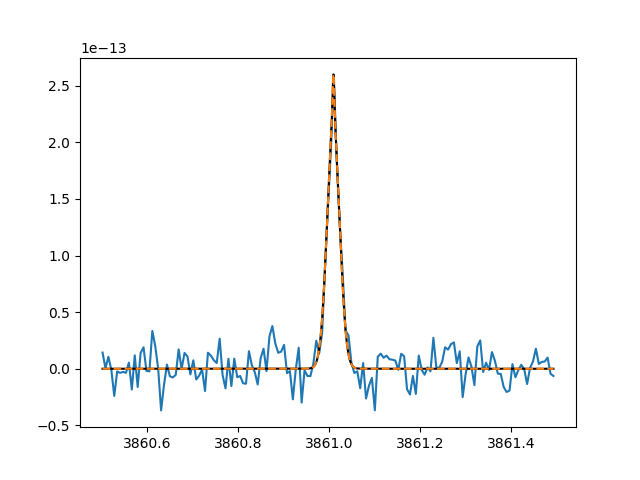

sigma_G = 0.014000 Å
fwhm_L  = 0.005000 Å
Gaussian area fraction (ratio) = 0.949409
Lorentz area fraction          = 0.050591


In [19]:
fwhm = 0.005
amplitude1 = 1e-13/2
x_0 = 3861.01
mean = x_0
amplitude2 = 2.1e-13
stddev=0.014
model = models.Lorentz1D(fwhm=fwhm, amplitude=amplitude1, x_0=x_0)
model += models.Gaussian1D(mean=mean, amplitude=amplitude2, stddev=stddev)
mask = (file['WAVE'] >= 3860.5) & (file['WAVE'] <= 3861.5)
x_fit = file['WAVE'][mask]
y_fit = file['FLUX_STACK'][mask] - file['CONTINUUM'][mask]
y_err = file['ERR_STACK'][mask]
x = np.linspace(x_fit.min(), x_fit.max(), 10000)

plt.figure()
plt.plot(x_fit, y_fit)
plt.plot(x, model(x), c='k')

fit = fitting.LevMarLSQFitter()
g_init = model
g_fit = fit(g_init, x_fit, y_fit, weights=1/y_err)


plt.plot(x, g_fit(x), linestyle='--')
plt.show()

# adjust indices depending on order: here 0 = Lorentz, 1 = Gaussian
A_L = g_fit.amplitude_0.value
fwhm_L = g_fit.fwhm_0.value

A_G = g_fit.amplitude_1.value
sigma_G = g_fit.stddev_1.value

area_L = A_L * np.pi * fwhm_L / 2.0
area_G = A_G * sigma_G * np.sqrt(2.0 * np.pi)

ratio = area_G / (area_G + area_L)

print(f"sigma_G = {sigma_G:.6f} Å")
print(f"fwhm_L  = {fwhm_L:.6f} Å")
print(f'Gaussian area fraction (ratio) = {ratio:.6f}')
print(f'Lorentz area fraction          = {1-ratio:.6f}')

def lsf(delta_lambda):
    gauss = np.exp(-0.5 * (delta_lambda / sigma_G)**2) / (sigma_G * np.sqrt(2.0 * np.pi))
    #lorentz in terms of fwhm_L
    A = 2/(np.pi*fwhm_L)
    gamma=fwhm_L/2
    lorentz = A*gamma**2 / (gamma**2 + (delta_lambda)**2)
    return ratio*gauss + (1-ratio)*lorentz
    

In [73]:
def filter_BX00_schleicher(df_all: pd.DataFrame,
                           r_h,
                           use_observed_only=False,
                           lambda_min_A=3800.0, lambda_max_A=3950.0,
                           use_obs_wavelength=False) -> pd.DataFrame:
    """
    Keep CN B–X(0,0) lines in a wavelength window, with a Schleicher-style N_max cut.
    No A-thresholding.
    """
    df = df_all.copy()
    lam_col = "lambda_vac_A_from_Obs" if use_obs_wavelength else "lambda_vac_A_from_Cal"

    # B–X (0–0) only, lower state X
    df = df[
        (df["eS'"] == "B") &
        (df["eS''"] == "X") &
        (df["v'"] == 0) &
        (df["v''"] == 0)
    ]

    # wavelength window around the violet 0–0 band
    df = df[(df[lam_col] >= lambda_min_A) & (df[lam_col] <= lambda_max_A)]

    if use_observed_only and "Obs" in df.columns:
        df = df[np.isfinite(df["Obs"])]

    # Apply Schleicher-style N_max using lower-state J'' as proxy
    Nmax = choose_Nmax_schleicher_style(r_h)

    # adapt column name to your Brooke file
    if "J''" in df.columns:
        j_col = "J''"
    elif "J_low" in df.columns:
        j_col = "J_low"
    else:
        raise KeyError("Cannot find lower-state J'' column for N_max cut")

    df = df[df[j_col] <= Nmax]

    return df
def choose_Nmax_schleicher_style(r_h):
    """
    Approximate N_max (actually J'' here) following Schleicher's guidance:
    include at least ~10 levels above the significantly populated range.
    This is conservative and should give converged L/N.
    """
    if r_h <= 0.4:
        return 39   # very strong pumping, populations up to ~45 => 60 is safe
    elif r_h <= 0.8:
        return 28   # 0.5–0.8 AU: typical relevant up to low 30s–40s
    elif r_h <= 1.5:
        return 21   # around 1 AU: relevant up to ~25–30
    elif r_h <= 3.0:
        return 16   # 2 AU-ish: relevant up to ~15–20
    else:
        return 20   # 4+ AU: relevant up to ~10, Nmax=20 is fine


def compare_with_schleicher(rdot, rsun):

    brooke_path = "CN_lines/12C14N.txt"
    df_all = load_cn_linelist(brooke_path)

    df = filter_BX00_schleicher(df_all,
                                r_h=rsun,
                                use_observed_only=False,
                                lambda_min_A=3800.0,
                                lambda_max_A=3950.0,
                                use_obs_wavelength=False)

    print("B–X(0,0) lines after filter:", df.shape[0])

    kuruz = pd.read_csv('kurucz_irradiance.txt', delim_whitespace=True, names=['nm', 'flux']) 
    kuruz['AA'] = kuruz['nm'] * 10.0
    wave = np.asarray(kuruz['AA'], dtype=float)
    flux = np.asarray(kuruz['flux'], dtype=float) 


    flux = flux * u.W / (u.m**2 * u.nm) 
    flux = flux.to(u.erg / (u.s * u.cm**2 * u.AA)) 
    flux = flux.value 
  
    flux *= 1.0 / rsun**2
    c_kms = const.c.to('km/s').value
    wave_shifted = wave * (1.0 + rdot / c_kms)
    pump_wave = wave_shifted
    pump_flux = flux

    # ==== 4) Build matrix (no A-cut here) ====
    lines = attach_pumping_and_labels(df, pump_wave, pump_flux,
                                      use_obs_wavelength=False,
                                      use_omega_labels=False)
    # add collisions

    M, idx2lvl, lines_out = build_rate_matrix_nbar(
        lines,
        include_stim_emission=True,
        verbose=True
    )

    # ==== 6) Solve populations (no collisions; Schleicher-style) ====
    n = solve_with_normalization(M, verbose=True)

    # ==== 7) g-factors, restrict to B–X Δv=0 ====
    g_ph, g_en, gtot_ph, gtot_en = g_factors(lines_out, n)
    lines_out["deltav"] = lines_out["v'"] - lines_out["v''"]
    mask_violet_dv0 = (lines_out["eS'"] == "B") & (lines_out["deltav"] == 0)

    L_over_N_violet_dv0 = np.sum(g_en[mask_violet_dv0])
    print(f"at {rsun} AU and rdot {rdot} km/s:",
          L_over_N_violet_dv0 * rsun**2)

compare_with_schleicher(rdot=0, rsun=1)

B–X(0,0) lines after filter: 124
[diag] N levels: 86 | M finite: True
[diag] n finite: True sum: 0.9999999999999998
at 1 AU and rdot 0 km/s: 2.4155530318851994e-13


/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_24970/415148470.py:73: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  kuruz = pd.read_csv('kurucz_irradiance.txt', delim_whitespace=True, names=['nm', 'flux'])


In [75]:
def filter_AX_BX(df_all: pd.DataFrame,
                 use_observed_only=False,
                 lambda_min_A=2990.0010, lambda_max_A=10009.9980,
                 use_obs_wavelength=False,
                 A_min=None) -> pd.DataFrame:
    """
    Keep CN B–X(0,0) and A–X(1,0) lines within wavelength window (Å),
    optionally only strong lines (A >= A_min).
    This is for your 'full' model, not Schleicher-style.
    """
    df = df_all.copy()
    lam_col = "lambda_vac_A_from_Obs" if use_obs_wavelength else "lambda_vac_A_from_Cal"

    # upper A or B, lower X
    df = df[(df["eS'"].isin(["A", "B"])) & (df["eS''"] == "X")]

    # B–X(0,0)
    m_B00 = (df["eS'"] == "B") & (df["v'"] == 0) & (df["v''"] == 0)

    # A–X(1,0): i.e. Δv = 1, lower v'' = 0
    m_A10 = (df["eS'"] == "A") & (df["v''"] == 0) & (df["v'"] - df["v''"] == 1)

    # keep both systems for pumping & cascades
    df = df[m_B00 | m_A10]

    # wavelength window
    df = df[(df[lam_col] >= lambda_min_A) & (df[lam_col] <= lambda_max_A)]

    if use_observed_only and "Obs" in df.columns:
        df = df[np.isfinite(df["Obs"])]

    # optional strong-line cut (YOUR choice, not Schleicher)
    if A_min is not None:
        df = df[df["A"] >= A_min]

    return df


def compare_full_model(rdot, rsun, A_min=1e4, Q_COLL=5e-3, T_COLL=270.0):

    # 1) Lines
    brooke_path = "CN_lines/12C14N.txt"
    df_all = load_cn_linelist(brooke_path)

    df = filter_AX_BX(df_all,
                      use_observed_only=False,
                      lambda_min_A=2990.0010,
                      lambda_max_A=10009.9980,
                      use_obs_wavelength=False,
                      A_min=A_min)

    print("Lines after filter:",
          df.shape[0], "(A_min =", A_min, ")")

    # 2) Solar spectrum
    kuruz = pd.read_csv('kurucz_irradiance.txt',
                        delim_whitespace=True, names=['nm', 'flux'])
    kuruz['AA'] = kuruz['nm'] * 10.0
    wave = np.asarray(kuruz['AA'], dtype=float)
    flux = np.asarray(kuruz['flux'], dtype=float)

    # W/m^2/nm -> erg/s/cm^2/Å
    flux = (flux * u.W / (u.m**2 * u.nm)).to(u.erg / (u.s * u.cm**2 * u.AA)).value

    # scale with r_h
    flux *= 1.0 / rsun**2

    # Doppler shift (Swings): shift solar spectrum into comet frame
    c_kms = const.c.to('km/s').value
    wave_shifted = wave * (1.0 + rdot / c_kms)

    pump_wave = wave_shifted
    pump_flux = flux

    # 3) Build matrix (A–X + B–X, strong lines only)
    lines = attach_pumping_and_labels(df, pump_wave, pump_flux,
                                      use_obs_wavelength=False,
                                      use_omega_labels=False)

    M, idx2lvl, lines_out = build_rate_matrix_nbar(
        lines,
        include_stim_emission=True,
        verbose=True
    )

    # 4) Add collisions (your choice)
    M = add_cn_collisions_to_M(
        M, lines_out, idx2lvl,
        Q=Q_COLL, T=T_COLL,
        include_deltaJ0=True,
        verbose=True
    )

    # 5) Solve populations
    n = solve_with_normalization(M, verbose=True)

    # 6) g-factors
    g_ph, g_en, gtot_ph, gtot_en = g_factors(lines_out, n)

    # 7) Sum only B–X Δv = 0 for comparison band
    lines_out["deltav"] = lines_out["v'"] - lines_out["v''"]
    mask_BX_dv0 = (
        (lines_out["eS'"] == "B") &
        (lines_out["eS''"] == "X") &
        (lines_out["deltav"] == 0)
    )

    L_over_N_BX_dv0_full = np.sum(g_en[mask_BX_dv0])

    print(f"[FULL] r_h={rsun} AU, rdot={rdot} km/s, "
          f"r_h^2 * (L/N)[B–X Δv=0] = {L_over_N_BX_dv0_full * rsun**2:.3e}")

    return L_over_N_BX_dv0_full

compare_full_model(rdot=-48, rsun=1.414, A_min=1e4, Q_COLL=5e-3, T_COLL=270.0)

Lines after filter: 770 (A_min = 10000.0 )
[diag] N levels: 562 | M finite: True
[collisions] Ground levels found: 144
[collisions] Added links: 356; Q=5.000e-03 s^-1, T=270.0 K
[diag] n finite: True sum: 1.0
[FULL] r_h=1.414 AU, rdot=-48 km/s, r_h^2 * (L/N)[B–X Δv=0] = 4.313e-13


/var/folders/qk/w_n1xnwj22176_k_hx_3sdf80000gn/T/ipykernel_24970/281855698.py:56: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  kuruz = pd.read_csv('kurucz_irradiance.txt',


np.float64(2.1571001626818155e-13)